## Bibliotecas

In [2]:
import pandas as pd                                              # Manipulação e análise de dados.
import re                                                        # Regex ou RegExp - Expressões Regulares (conhecidas como Regex ou RegExp) - Extração de Informação - Limpeza de Dados.
from nltk.corpus import stopwords                                # Processamento de Linguagem Natural (NLP) - stopwords (Palavras de Parada) não carregam um significado semântico relevante.
import nltk
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer                          # Padronizar o "sentido" das palavras.
nltk.download('wordnet')                                         # Banco de dados lexical da língua inglesa que o NLTK usa para entender as relações entre as palavras.
nltk.download('omw-1.4')                                         # É uma extensão que melhora o suporte a vários idiomas e variantes de significado.
from collections import Counter                                  # Serve para contar a frequência de elementos em uma lista.
from nltk.stem import PorterStemmer                              # Stemming - corta o sufixo da palavra para chegar ao radical.
from pandarallel import pandarallel                              # Permite que o .apply() use todos os núcleos do seu processador
import nltk
from nltk.tokenize import word_tokenize                          # Quebra uma frase inteira em uma lista de palavras e pontuações, chamadas de Tokens.
from gensim.models import Word2Vec                               # Entender o significado das palavras através de números. Transformação em Vetores.
import numpy as np                                               # Cálculo científico e análise de dados.
from nltk.sentiment.vader import SentimentIntensityAnalyzer      # VADER - modelo baseado em regras (dicionário) projetado especificamente para expressar a intensidade do sentimento em textos.     
from collections import Counter                                  # Contador.
from transformers import pipeline                                # Permite usar modelos Transformer - Inteligência Artificia - Hugging Face.
from sklearn.linear_model import LogisticRegression              # Algoritmo de classificação.
from sklearn.model_selection import train_test_split             # Separa os dados.
from sklearn.metrics import classification_report, accuracy_score     # Réguas de medição.
from sklearn.metrics import confusion_matrix                     # Faz a contabilidade dos erros e acertos.
import seaborn as sns                                            # Visualização de dados baseada em estatística.
import matplotlib.pyplot as plt                                  # Gráficos.
from sklearn.metrics import roc_auc_score                        # Avalia a capacidade do modelo de separar as classes (Positiva x Negativa)
from sklearn.model_selection import cross_val_score              # Validação Cruzada.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\marco\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\marco\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\marco\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
# ! pip install wordcloud matplotlib
# ! pip install pandarallel
# ! pip install ipywidgets
# ! pip install gensim

## Base de Dados -  Conhecendo e explorando

Nesta parte do código carregamos a Base de Dados do site:  https://cfpb.github.io/api/ccdb/index.html.
Aplicamos um rigoroso tratamento de dados para eliminar registros nulos e duplicados, garantindo a integridade da análise e evitando vieses de repetição.

In [3]:
df = pd.read_csv('complaints.csv')

In [4]:
df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2019-12-26,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,NaN,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,94025,NaN,Consent not provided,Web,2019-12-26,Closed with explanation,Yes,NaN,3477549
2,2020-05-08,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,These are not my accounts.,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,NV,89030,NaN,Consent provided,Web,2020-05-08,Closed with explanation,Yes,NaN,3642453
3,2024-01-05,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,Kindly address this issue on my credit report....,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,IL,60502,NaN,Consent provided,Web,2024-01-05,Closed with non-monetary relief,Yes,NaN,8113747
4,2024-01-21,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,NC,27401,Servicemember,Consent not provided,Web,2024-01-21,Closed with explanation,Yes,NaN,8191825


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13689875 entries, 0 to 13689874
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(17)
memory usage: 1.

In [6]:
df.isnull().sum()

Date received                          0
Product                                0
Sub-product                       235291
Issue                                  6
Sub-issue                         889209
Consumer complaint narrative     9958646
Company public response          6376418
Company                                0
State                              59442
ZIP code                           30225
Tags                            12971205
Consumer consent provided?       2049368
Submitted via                          0
Date sent to company                   0
Company response to consumer          21
Timely response?                       0
Consumer disputed?              12921680
Complaint ID                           0
dtype: int64

In [7]:
# Criando um novo dataframe excluindo os valores nulos (sem narrativa)
df_narrativas = df[df['Consumer complaint narrative'].notnull()]

In [8]:
# Criando o novo DataFrame com as duas colunas
df_nlp = df_narrativas[['Consumer complaint narrative','Product']].copy()
df_nlp.head(5)

,Consumer complaint narrative,Product
2,These are not my accounts.,"Credit reporting, credit repair services, or o..."
3,Kindly address this issue on my credit report....,Credit reporting or other personal consumer re...
5,"I wrote three requests, the unverified account...","Credit reporting, credit repair services, or o..."
6,XXXX XXXX has a old account settled in XXXX th...,"Credit reporting, credit repair services, or o..."
7,They call at all hours and on the weekends usi...,Student loan


In [9]:
# Verificando o tamanho real
print(f"Novo DataFrame criado com {len(df_nlp)} linhas.")
df_nlp.head(5)

Novo DataFrame criado com 3731229 linhas.


,Consumer complaint narrative,Product
2,These are not my accounts.,"Credit reporting, credit repair services, or o..."
3,Kindly address this issue on my credit report....,Credit reporting or other personal consumer re...
5,"I wrote three requests, the unverified account...","Credit reporting, credit repair services, or o..."
6,XXXX XXXX has a old account settled in XXXX th...,"Credit reporting, credit repair services, or o..."
7,They call at all hours and on the weekends usi...,Student loan


In [10]:
# Contar duplicados apenas na coluna de texto
duplicados_texto = df_nlp.duplicated(subset=['Consumer complaint narrative']).sum()
print(f"Existem {duplicados_texto} narrativas repetidas.")

Existem 1242259 narrativas repetidas.


In [11]:
# Remove as duplicadas e mantém apenas a primeira ocorrência de cada
df_nlp = df_nlp.drop_duplicates(subset=['Consumer complaint narrative'], keep='first')

print(f"Tamanho do DataFrame após a limpeza: {len(df_nlp)}")

Tamanho do DataFrame após a limpeza: 2488970


## Limpeza dos dados

Efetuamos a limpeza de dados, transformando todas as palavras em minúsculas, removermos palavras que não
são relevantes, reduzimos a complexidade do vocabulário usando: stopwords, lematização e stemming para
facilitar o aprendizado e a classificação do sentimento.

In [12]:
# Transformar em minúsculas e remover palavras que não são relevantes  =  1m 43.9s
 
def limpeza_basica(texto):
    # 1. Transformar em minúsculas
    texto = texto.lower()
    # 2. Remover os "XXXX" (dados mascarados)
    texto = re.sub(r'x{2,}', '', texto)
    # 3. Remover números e pontuação (manter apenas letras)
    texto = re.sub(r'[^a-z\s]', '', texto)
    # 4. Remover espaços extras
    texto = " ".join(texto.split())
    return texto

# Aplicando a limpeza
df_nlp['narrativa_limpa'] = df_nlp['Consumer complaint narrative'].apply(limpeza_basica)
df_nlp.head(5)

,Consumer complaint narrative,Product,narrativa_limpa
2,These are not my accounts.,"Credit reporting, credit repair services, or o...",these are not my accounts
3,Kindly address this issue on my credit report....,Credit reporting or other personal consumer re...,kindly address this issue on my credit report ...
5,"I wrote three requests, the unverified account...","Credit reporting, credit repair services, or o...",i wrote three requests the unverified accounts...
6,XXXX XXXX has a old account settled in XXXX th...,"Credit reporting, credit repair services, or o...",has a old account settled in that keeps reappe...
7,They call at all hours and on the weekends usi...,Student loan,they call at all hours and on the weekends usi...


In [13]:
# stopwords

stop_words = set(stopwords.words('english'))

def remover_stopwords(texto):
    palavras = texto.split()
    return " ".join([p for p in palavras if p not in stop_words])

# Aplicando a remoção
df_nlp['narrativa_limpa'] = df_nlp['narrativa_limpa'].apply(remover_stopwords)
df_nlp.head(5)

,Consumer complaint narrative,Product,narrativa_limpa
2,These are not my accounts.,"Credit reporting, credit repair services, or o...",accounts
3,Kindly address this issue on my credit report....,Credit reporting or other personal consumer re...,kindly address issue credit report assert acco...
5,"I wrote three requests, the unverified account...","Credit reporting, credit repair services, or o...",wrote three requests unverified accounts liste...
6,XXXX XXXX has a old account settled in XXXX th...,"Credit reporting, credit repair services, or o...",old account settled keeps reappearing experian...
7,They call at all hours and on the weekends usi...,Student loan,call hours weekends using various numbers


In [14]:
# lematização    =   9m 59.0s

lemmatizer = WordNetLemmatizer()

def lematizar(texto):
    return " ".join([lemmatizer.lemmatize(p) for p in texto.split()])

# Aplicando a lematização
df_nlp['narrativa_limpa'] = df_nlp['narrativa_limpa'].apply(lematizar)
df_nlp.head(5)

,Consumer complaint narrative,Product,narrativa_limpa
2,These are not my accounts.,"Credit reporting, credit repair services, or o...",account
3,Kindly address this issue on my credit report....,Credit reporting or other personal consumer re...,kindly address issue credit report assert acco...
5,"I wrote three requests, the unverified account...","Credit reporting, credit repair services, or o...",wrote three request unverified account listed ...
6,XXXX XXXX has a old account settled in XXXX th...,"Credit reporting, credit repair services, or o...",old account settled keep reappearing experian ...
7,They call at all hours and on the weekends usi...,Student loan,call hour weekend using various number


In [15]:
# Aplicando o Stemming usando todos os núcleos do meu PC        =  6m 24.8s

# Progress_bar 
pandarallel.initialize(progress_bar=True)

def aplicar_stemming_paralelo(texto):
    
    from nltk.stem import PorterStemmer
    local_stemmer = PorterStemmer()
    
    if isinstance(texto, str):
        return " ".join([local_stemmer.stem(p) for p in texto.split()])
    return ""

# Usando o parallel_apply
df_nlp['narrativa_stemmed'] = df_nlp['narrativa_limpa'].parallel_apply(aplicar_stemming_paralelo)

# Verifique o resultado
df_nlp.head(5)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

https://nalepae.github.io/pandarallel/troubleshooting/


,Consumer complaint narrative,Product,narrativa_limpa,narrativa_stemmed
2,These are not my accounts.,"Credit reporting, credit repair services, or o...",account,account
3,Kindly address this issue on my credit report....,Credit reporting or other personal consumer re...,kindly address issue credit report assert acco...,kindli address issu credit report assert accou...
5,"I wrote three requests, the unverified account...","Credit reporting, credit repair services, or o...",wrote three request unverified account listed ...,wrote three request unverifi account list stil...
6,XXXX XXXX has a old account settled in XXXX th...,"Credit reporting, credit repair services, or o...",old account settled keep reappearing experian ...,old account settl keep reappear experian credi...
7,They call at all hours and on the weekends usi...,Student loan,call hour weekend using various number,call hour weekend use variou number


## Tokenização

In [16]:
# Tokenização     =  10m 12.1s

# Garante que o recurso de tokenização está baixado
nltk.download('punkt')

# Criando a nova coluna de tokens
df_nlp['tokens_stemmed'] = df_nlp['narrativa_stemmed'].apply(word_tokenize)

# Visualizando o resultado
print(df_nlp[['narrativa_stemmed', 'tokens_stemmed']].head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\marco\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                   narrativa_stemmed  \
2                                            account   
3  kindli address issu credit report assert accou...   
5  wrote three request unverifi account list stil...   
6  old account settl keep reappear experian credi...   
7                call hour weekend use variou number   

                                      tokens_stemmed  
2                                          [account]  
3  [kindli, address, issu, credit, report, assert...  
5  [wrote, three, request, unverifi, account, lis...  
6  [old, account, settl, keep, reappear, experian...  
7         [call, hour, weekend, use, variou, number]  


In [17]:
# Junta todos os tokens em uma única lista e conta os únicos 
vocabulario = set([token for lista in df_nlp['tokens_stemmed'] for token in lista])
print(f"Seu vocabulário atual possui {len(vocabulario)} palavras únicas.")

Seu vocabulário atual possui 338765 palavras únicas.


## Modelando o problema

- Utilizamos Word2Vec para transformar textos em vetores de 100 dimensões, capturando o contexto semântico das reclamações financeiras.
- Aplicamos o modelo léxico VADER para a classificação inicial. Após uma auditoria qualitativa com o modelo Transformer (BERT) do Hugging Face, ajustamos o threshold de sentimento positivo para 0.70, elevando o rigor e a qualidade do nosso Target.
- Para modelagem e treino escolhemos a Regressão Logística pelo equilíbrio entre performance (velocidade em linhas) e interpretabilidade.
- Conseguimos uma acurácia de 64%, AUC de 0.82 e uma Validação Cruzada (STD 0.29%).
- Salvamos o modelo o data frame para utilização futuras, reduzindo o tempo e recursos em caso de falha no sistema e para futuras utilizações. 

In [18]:
# Transformação em Vetores        # 9m 56.5s

sentencas = df_nlp['tokens_stemmed'].tolist()

# Treinando o modelo de Embedding
# vector_size=100: cada palavra vira 100 números
# window=5: ele olha 5 palavras antes e depois para entender o contexto
# min_count=10: ignora palavras que aparecem menos de 10 vezes (como você fez no vocabulário)
modelo_w2v = Word2Vec(sentences=sentencas, vector_size=100, window=5, min_count=10, workers=4)

In [19]:
# Quais palavras o modelo acha que se parecem com "fee" (taxa)?
# Validação Qualitativa, demonstra que o Word2Vec conseguiu agrupar palavras por contexto.

print("Palavras similares a 'fee':")
print(modelo_w2v.wv.most_similar('fee'))

# E com "fraud" (fraude)?
print("\nPalavras similares a 'fraud':")
print(modelo_w2v.wv.most_similar('fraud'))

Palavras similares a 'fee':
[('fe', 0.7462983131408691), ('feesi', 0.6570731997489929), ('surcharg', 0.6462445259094238), ('feee', 0.6381468176841736), ('latefe', 0.630010724067688), ('hefti', 0.6236211657524109), ('feeslat', 0.6229442358016968), ('feesfin', 0.6227894425392151), ('feesinterest', 0.618904173374176), ('feeaccount', 0.6056678295135498)]

Palavras similares a 'fraud':
[('fruad', 0.715944230556488), ('fraudscam', 0.5880426168441772), ('fraudi', 0.5704852342605591), ('fradul', 0.5448899865150452), ('frud', 0.5434218645095825), ('fraudul', 0.521327555179596), ('scam', 0.5210283398628235), ('fraudster', 0.5175639986991882), ('frad', 0.5128765106201172), ('freud', 0.5102194547653198)]


In [20]:
# Transforma o texto em números      # 7m 41.8s

def vetor_medio(tokens, modelo):
    # Pega os vetores das palavras que existem no modelo
    vetores = [modelo.wv[word] for word in tokens if word in modelo.wv]
    if len(vetores) == 0:
        return np.zeros(100)
    # Retorna a média de todos os vetores da frase
    return np.mean(vetores, axis=0)

# Criando a nova matriz de características (X_emb)
X_emb = np.array([vetor_medio(t, modelo_w2v) for t in df_nlp['tokens_stemmed']])

print(f"Sua nova matriz X tem formato: {X_emb.shape}")

Sua nova matriz X tem formato: (2488970, 100)


In [21]:
# VADER - Modelo de dicionário          # 28m 39.s


sia = SentimentIntensityAnalyzer()

# Cria a função de rótulo   -   sentimento
def rotular_sentimento(texto):
    score = sia.polarity_scores(str(texto))['compound']
    return 'Positiva' if score > 0 else 'Negativa'

df_nlp['sentimento'] = df_nlp['narrativa_limpa'].apply(rotular_sentimento)

print(df_nlp[['narrativa_limpa', 'sentimento']].head())

                                     narrativa_limpa sentimento
2                                            account   Negativa
3  kindly address issue credit report assert acco...   Positiva
5  wrote three request unverified account listed ...   Negativa
6  old account settled keep reappearing experian ...   Positiva
7             call hour weekend using various number   Positiva


In [22]:
# Verificar a quantidade de reclamação por sentimentos 
print(Counter(df_nlp['sentimento']))

Counter({'Positiva': 1286909, 'Negativa': 1202061})


In [23]:
# Criação do Target com uso de theshold          # 27m 53.0s        

def rotular_sentimento_ajustado(texto):     
    score = sia.polarity_scores(str(texto))['compound']
    # Só considera positiva se o score for realmente alto
    if score > 0.35: 
        return 'Positiva'
    # Você pode até criar uma classe 'Neutra' para scores entre -0.1 e 0.35
    else:
        return 'Negativa'

df_nlp['sentimento'] = df_nlp['narrativa_limpa'].apply(rotular_sentimento_ajustado)

In [24]:
print(Counter(df_nlp['sentimento']))

Counter({'Negativa': 1449815, 'Positiva': 1039155})


In [25]:
df_nlp.head(10)

,Consumer complaint narrative,Product,narrativa_limpa,narrativa_stemmed,tokens_stemmed,sentimento
2,These are not my accounts.,"Credit reporting, credit repair services, or o...",account,account,[account],Negativa
3,Kindly address this issue on my credit report....,Credit reporting or other personal consumer re...,kindly address issue credit report assert acco...,kindli address issu credit report assert accou...,"[kindli, address, issu, credit, report, assert...",Positiva
5,"I wrote three requests, the unverified account...","Credit reporting, credit repair services, or o...",wrote three request unverified account listed ...,wrote three request unverifi account list stil...,"[wrote, three, request, unverifi, account, lis...",Negativa
6,XXXX XXXX has a old account settled in XXXX th...,"Credit reporting, credit repair services, or o...",old account settled keep reappearing experian ...,old account settl keep reappear experian credi...,"[old, account, settl, keep, reappear, experian...",Negativa
7,They call at all hours and on the weekends usi...,Student loan,call hour weekend using various number,call hour weekend use variou number,"[call, hour, weekend, use, variou, number]",Negativa
10,I was recently going to check out a new car at...,"Credit reporting, credit repair services, or o...",recently going check new car carefully conside...,recent go check new car care consider decid ap...,"[recent, go, check, new, car, care, consider, ...",Positiva
15,XXXX claimed they delivered a package to my ad...,Credit card or prepaid card,claimed delivered package address never receiv...,claim deliv packag address never receiv list d...,"[claim, deliv, packag, address, never, receiv,...",Positiva
21,I got a Brinks Money pre-paid card in the mail...,Credit card or prepaid card,got brink money prepaid card mail assuming une...,got brink money prepaid card mail assum unempl...,"[got, brink, money, prepaid, card, mail, assum...",Negativa
22,I have filed a dispute in regards to the incor...,"Credit reporting, credit repair services, or o...",filed dispute regard incorrect information tha...,file disput regard incorrect inform that credi...,"[file, disput, regard, incorrect, inform, that...",Positiva
33,There are five closed accounts from XXXX on my...,"Credit reporting, credit repair services, or o...",five closed account credit report still closed...,five close account credit report still close h...,"[five, close, account, credit, report, still, ...",Negativa


In [26]:
# Usar Hugging Face - comparando com VADER 

import pandas as pd

# Carregar o modelo 
# Usamos o 'distilbert', que é uma versão leve e rápida do BERT
classificador_hf = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Pegar uma amostra de 10 linhas (5 de cada classe do seu VADER)
amostra_pos = df_nlp[df_nlp['sentimento'] == 'Positiva'].sample(5, random_state=42)
amostra_neg = df_nlp[df_nlp['sentimento'] == 'Negativa'].sample(5, random_state=42)
df_teste = pd.concat([amostra_pos, amostra_neg])

print(f"{'Texto Resumido':<50} | {'VADER':<10} | {'HuggingFace':<15}")
print("-" * 85)

for _, linha in df_teste.iterrows():
    texto = str(linha['narrativa_limpa'])
    vader_label = linha['sentimento']
    
    # O BERT tem um limite de 512 tokens. Vamos cortar o texto para garantir.
    resultado_hf = classificador_hf(texto[:512])[0]
    
    # Ajustando o nome do rótulo do Hugging Face para comparar
    hf_label = 'Positiva' if resultado_hf['label'] == 'POSITIVE' else 'Negativa'
    confianca = resultado_hf['score']
    
    print(f"{texto[:47]+'...':<50} | {vader_label:<10} | {hf_label} ({confianca:.2f})")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Texto Resumido                                     | VADER      | HuggingFace    
-------------------------------------------------------------------------------------
accordance fair credit reporting act list accou... | Positiva   | Negativa (0.99)
merchant charged credit card deposit urgent car... | Positiva   | Negativa (1.00)
credit report account titled account number sol... | Positiva   | Negativa (1.00)
disputed information collection account hunter ... | Positiva   | Negativa (1.00)
good day received letter today asking complaint... | Positiva   | Negativa (0.97)
im submitting complaint today inform victim ide... | Negativa   | Negativa (1.00)
dont know inquiry like please delete one id vic... | Negativa   | Negativa (1.00)
company ocwen wanted make monthly payment paid ... | Negativa   | Negativa (0.99)
delinquent student loan original amount total a... | Negativa   | Negativa (1.00)
victim identity theft fraudulent account placed... | Negativa   | Negativa (1.00)


In [27]:
# Ajusta o Pandas para mostrar todo o conteúdo da célula
pd.set_option('display.max_colwidth', None)

# Mostra as 5 primeiras narrativas de moedas virtuais
for i, texto in enumerate(df_nlp['narrativa_limpa'].head(5), 1):
    print(f"--- Reclamação {i} ---")
    print(texto)
    print("\n")

--- Reclamação 1 ---
account


--- Reclamação 2 ---
kindly address issue credit report assert account mine believe fraudulent urge correct mistake provided supporting document verification


--- Reclamação 3 ---
wrote three request unverified account listed still remain credit report violation federal law equifax fcra law obtain original creditor documentation file verify information mine correct already filed ftc report police report verified account provided copy original documentation consumer contract signature required section section furthermore failed provide method verification required section please advised section fcra required promptly delete information verified law clear civil liability remedy available section fail comply federal law litigious consumer fully intend pursuing litigation matter enforce right fcra please remove following account


--- Reclamação 4 ---
old account settled keep reappearing experian credit report state debt settled balance total lie incorrect s

In [28]:
# Redefinindo o score do sentimento  - VADER X HuggingFace        # 30m 48.3s
# Depois de usar o HugginFace, verifiquei a necessiade de alterar o theshold.


def rotular_vader_pro(texto):            
    score = sia.polarity_scores(str(texto))['compound']
    if score > 0.70: 
        return 'Positiva' # Só elogios explícitos
    elif score < -0.10:
        return 'Negativa' # Reclamações claras
    else:
        return 'Neutra/Dúvida' # Onde o VADER costuma errar

df_nlp['sentimento'] = df_nlp['narrativa_limpa'].apply(rotular_vader_pro)

In [29]:
df_nlp.head(5)

,Consumer complaint narrative,Product,narrativa_limpa,narrativa_stemmed,tokens_stemmed,sentimento
2,These are not my accounts.,"Credit reporting, credit repair services, or other personal consumer reports",account,account,[account],Neutra/Dúvida
3,Kindly address this issue on my credit report. I assert that this account is not mine and believe it to be fraudulent. I urge you to correct this mistake and have provided supporting documents for verification.,Credit reporting or other personal consumer reports,kindly address issue credit report assert account mine believe fraudulent urge correct mistake provided supporting document verification,kindli address issu credit report assert account mine believ fraudul urg correct mistak provid support document verif,"[kindli, address, issu, credit, report, assert, account, mine, believ, fraudul, urg, correct, mistak, provid, support, document, verif]",Neutra/Dúvida
5,"I wrote three requests, the unverified accounts listed below still remain on my credit report in violation of Federal Law. Equifax is under FCRA law to obtain the of the original creditors documentation on file to verify that this information is mine and is correct. I have already filed a FTC Report and Police Report. Who verified these accounts? You have NOT provided me a copy of ANY original documentation ( a consumer contract with my signature on it ) as required under Section 609 ( a ) ( 1 ) ( A ) & Section 611 ( a ) ( 1 ) ( A ). Furthermore you have failed to provide the method of verification as required under Section 611 ( a ) ( 7 ). Please be advised that under Section 611 ( 5 ) ( A ) of the FCRA you are required to promptly DELETE all information which can not be verified. \nThe law is very clear as to the Civil liability and the remedy available to me ( Section 616 & 617 ) if you fail to comply with Federal Law. I am a litigious consumer and fully intend on pursuing litigation in this matter to enforce my rights under the FCRA. Please remove the following accounts : XXXX XXXX XXXX XXXX XXXX, XXXX XXXX XXXX XXXX","Credit reporting, credit repair services, or other personal consumer reports",wrote three request unverified account listed still remain credit report violation federal law equifax fcra law obtain original creditor documentation file verify information mine correct already filed ftc report police report verified account provided copy original documentation consumer contract signature required section section furthermore failed provide method verification required section please advised section fcra required promptly delete information verified law clear civil liability remedy available section fail comply federal law litigious consumer fully intend pursuing litigation matter enforce right fcra please remove following account,wrote three request unverifi account list still remain credit report violat feder law equifax fcra law obtain origin creditor document file verifi inform mine correct alreadi file ftc report polic report verifi account provid copi origin document consum contract signatur requir section section furthermor fail provid method verif requir section pleas advis section fcra requir promptli delet inform verifi law clear civil liabil remedi avail section fail compli feder law litigi consum fulli intend pursu litig matter enforc right fcra pleas remov follow account,"[wrote, three, request, unverifi, account, list, still, remain, credit, report, violat, feder, law, equifax, fcra, law, obtain, origin, creditor, document, file, verifi, inform, mine, correct, alreadi, file, ftc, report, polic, report, verifi, account, provid, copi, origin, document, consum, contract, signatur, requir, section, section, furthermor, fail, provid, method, verif, requir, section, pleas, advis, section, fcra, requir, promptli, delet, inform, verifi, law, clear, civil, liabil, remedi, avail, section, fail, compli, feder, law, litigi, consum, fulli, intend, pursu, litig, matter, enforc, right, fcra, pleas, remov, follow

In [30]:
print(Counter(df_nlp['sentimento']))

Counter({'Negativa': 1082532, 'Neutra/Dúvida': 736304, 'Positiva': 670134})


In [31]:
# Inicio do treino

# Definimos o alvo (y)
y = df_nlp['sentimento']

# Dividimos os dados 
X_train_emb, X_test_emb, y_train, y_test = train_test_split(
    X_emb, y, test_size=0.2, random_state=42
)

# Inicializamos e treinamos a Regressão Logística

modelo_final = LogisticRegression(max_iter=1000)
modelo_final.fit(X_train_emb, y_train)

# Fazemos as previsões
y_pred_emb = modelo_final.predict(X_test_emb)

In [32]:
print("--- Resultado do Modelo com Embeddings ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_emb):.2%}")
print("\nRelatório de Performance:")
print(classification_report(y_test, y_pred_emb))

--- Resultado do Modelo com Embeddings ---
Acurácia: 64.37%

Relatório de Performance:
               precision    recall  f1-score   support

     Negativa       0.71      0.82      0.76    216057
Neutra/Dúvida       0.53      0.43      0.47    147938
     Positiva       0.63      0.61      0.62    133799

     accuracy                           0.64    497794
    macro avg       0.62      0.62      0.62    497794
 weighted avg       0.63      0.64      0.63    497794



In [33]:
# Testes do treino

def testar_sentimento(frase):
    # Limpa e tokeniza a frase 
    tokens = word_tokenize(aplicar_stemming_paralelo(limpeza_basica(frase)))
    # Transforma em vetor médio
    vetor = vetor_medio(tokens, modelo_w2v).reshape(1, -1)
    # Prediz
    resultado = modelo_final.predict(vetor)
    return resultado[0]

# Teste 1
print(f"Frase: 'I love how they solved my problem' -> Sentimento: {testar_sentimento('I love how they solved my problem')}")

# Teste 2
print(f"Frase: 'This bank is a disaster, terrible service' -> Sentimento: {testar_sentimento('This bank is a disaster, terrible service')}")

Frase: 'I love how they solved my problem' -> Sentimento: Positiva
Frase: 'This bank is a disaster, terrible service' -> Sentimento: Negativa


In [34]:
# Testes do treino

def testar_sentimento_diagnostico(frase):
    # Limpeza
    passo1 = limpeza_basica(frase)
    passo2 = aplicar_stemming_paralelo(passo1)
    tokens = word_tokenize(passo2)
    
    # Veja o que sobrou:
    print(f"Tokens após limpeza: {tokens}")
    
    # Verifica quais tokens REALMENTE existem no modelo Word2Vec
    tokens_no_modelo = [t for t in tokens if t in modelo_w2v.wv]
    print(f"Tokens que o modelo conhece: {tokens_no_modelo}")
    
    if not tokens_no_modelo:
        return "Modelo não conhece nenhuma palavra desta frase!"
        
    # Resto do processo...
    vetor = vetor_medio(tokens, modelo_w2v).reshape(1, -1)
    return modelo_final.predict(vetor)[0]

# Teste com palavras que COM CERTEZA estão no seu dataset:
print(f"Resultado: {testar_sentimento_diagnostico('I love how they solved my problem')}")
print(f"Resultado: {testar_sentimento_diagnostico('This bank is a disaster, terrible service')}")

Tokens após limpeza: ['i', 'love', 'how', 'they', 'solv', 'my', 'problem']
Tokens que o modelo conhece: ['i', 'love', 'how', 'they', 'solv', 'my', 'problem']
Resultado: Positiva
Tokens após limpeza: ['thi', 'bank', 'is', 'a', 'disast', 'terribl', 'servic']
Tokens que o modelo conhece: ['thi', 'bank', 'a', 'disast', 'terribl', 'servic']
Resultado: Negativa


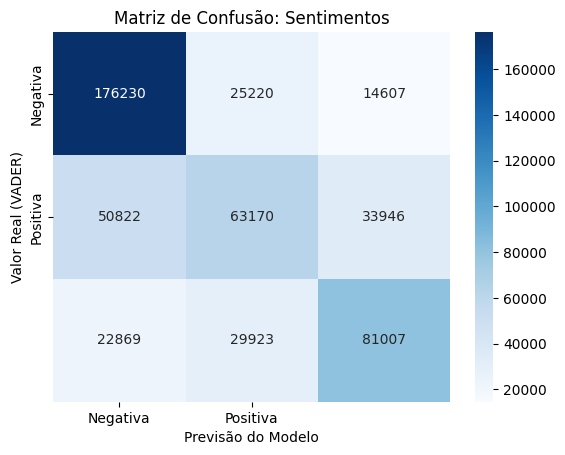

In [35]:
# Matriz de Confusão

cm = confusion_matrix(y_test, y_pred_emb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negativa', 'Positiva'], 
            yticklabels=['Negativa', 'Positiva'])
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real (VADER)')
plt.title('Matriz de Confusão: Sentimentos')
plt.show()

In [36]:
# Tabela de performance

#from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_emb))

               precision    recall  f1-score   support

     Negativa       0.71      0.82      0.76    216057
Neutra/Dúvida       0.53      0.43      0.47    147938
     Positiva       0.63      0.61      0.62    133799

     accuracy                           0.64    497794
    macro avg       0.62      0.62      0.62    497794
 weighted avg       0.63      0.64      0.63    497794



In [37]:
# Avalia a capacidade do modelo de separar as classes (Positiva x Negativa)

# Probabilidades de TODAS as 3 classes 
y_probs_todas = modelo_final.predict_proba(X_test_emb)

auc = roc_auc_score(y_test, y_probs_todas, multi_class='ovr', average='weighted')

print(f"AUC-ROC Multiclasse (Weighted): {auc:.4f}")

AUC-ROC Multiclasse (Weighted): 0.8185


In [38]:
# Amostra aleatória de 100 mil registros

# Reseta os índices do DataFrame para ficarem de 0 até o final, combinando com a matriz
df_nlp_reset = df_nlp.reset_index(drop=True)

# Agora sim, pegamos a amostra do DataFrame resetado
df_amostra = df_nlp_reset.sample(100000, random_state=42)

# Agora os índices da amostra vão bater perfeitamente com as linhas da matriz X_emb
X_amostra = X_emb[df_amostra.index]
y_amostra = df_amostra['sentimento']

# Rodando a validação cruzada
# from sklearn.model_selection import cross_val_score
scores = cross_val_score(modelo_final, X_amostra, y_amostra, cv=5)

print(f"Acurácia Média (CV): {scores.mean():.2%} (+/- {scores.std():.2%})")

Acurácia Média (CV): 64.24% (+/- 0.20%)


In [ ]:
# import joblib

# # Salvando o classificador (Ex: LogisticRegression ou RandomForest)
# joblib.dump(modelo_final, 'modelo_sentimento.pkl')

# # Salvando o Word2Vec (ele tem um método próprio mais eficiente)
# modelo_w2v.save("modelo_word2vec.model")

# print("Modelos salvos com sucesso! 🚀")

Modelos salvos com sucesso! 🚀


In [ ]:
# # Salvando o DataFrame completo
# df_nlp.to_csv('resultado_datathon.csv', index=False, encoding='utf-8')
# print("Arquivo CSV salvo com sucesso!")

Arquivo CSV salvo com sucesso!


# Deep Leaning

- Segundo momento do projeto - evoluir do Machine Learning Clássico para Deep Learning.
- Evoluímos para o uso de Redes Neurais Recorrentes (LSTM). Ao contrário do modelo clássico, a LSTM preserva a ordem das palavras, 
essencial para entender a jornada do cliente na reclamação.
- Trabalhamos com uma amostra estratificada de 100.000 registros, balanceando o poder computacional com a necessidade de Big Data.
- Utilizamos a Matriz de Confusão como ferramenta principal para confrontar os modelos. O Deep Learning demonstrou uma superioridade nítida, 
elevando a acurácia para 83,38% e reduzindo drasticamente os falsos negativos em reclamações críticas.

In [ ]:
# ! pip install transformers
# ! pip install torch
# ! pip install tensorflow
# ! pip install tensorflow.keras.preprocessing.text


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement tensorflow.keras.preprocessing.text (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow.keras.preprocessing.text


In [42]:
import torch
from transformers import pipeline
print(f"Versão do Torch: {torch.__version__}")

Versão do Torch: 2.10.0+cpu


In [43]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [44]:
df_nlp.head(5)

,Consumer complaint narrative,Product,narrativa_limpa,narrativa_stemmed,tokens_stemmed,sentimento
2,These are not my accounts.,"Credit reporting, credit repair services, or other personal consumer reports",account,account,[account],Neutra/Dúvida
3,Kindly address this issue on my credit report. I assert that this account is not mine and believe it to be fraudulent. I urge you to correct this mistake and have provided supporting documents for verification.,Credit reporting or other personal consumer reports,kindly address issue credit report assert account mine believe fraudulent urge correct mistake provided supporting document verification,kindli address issu credit report assert account mine believ fraudul urg correct mistak provid support document verif,"[kindli, address, issu, credit, report, assert, account, mine, believ, fraudul, urg, correct, mistak, provid, support, document, verif]",Neutra/Dúvida
5,"I wrote three requests, the unverified accounts listed below still remain on my credit report in violation of Federal Law. Equifax is under FCRA law to obtain the of the original creditors documentation on file to verify that this information is mine and is correct. I have already filed a FTC Report and Police Report. Who verified these accounts? You have NOT provided me a copy of ANY original documentation ( a consumer contract with my signature on it ) as required under Section 609 ( a ) ( 1 ) ( A ) & Section 611 ( a ) ( 1 ) ( A ). Furthermore you have failed to provide the method of verification as required under Section 611 ( a ) ( 7 ). Please be advised that under Section 611 ( 5 ) ( A ) of the FCRA you are required to promptly DELETE all information which can not be verified. \nThe law is very clear as to the Civil liability and the remedy available to me ( Section 616 & 617 ) if you fail to comply with Federal Law. I am a litigious consumer and fully intend on pursuing litigation in this matter to enforce my rights under the FCRA. Please remove the following accounts : XXXX XXXX XXXX XXXX XXXX, XXXX XXXX XXXX XXXX","Credit reporting, credit repair services, or other personal consumer reports",wrote three request unverified account listed still remain credit report violation federal law equifax fcra law obtain original creditor documentation file verify information mine correct already filed ftc report police report verified account provided copy original documentation consumer contract signature required section section furthermore failed provide method verification required section please advised section fcra required promptly delete information verified law clear civil liability remedy available section fail comply federal law litigious consumer fully intend pursuing litigation matter enforce right fcra please remove following account,wrote three request unverifi account list still remain credit report violat feder law equifax fcra law obtain origin creditor document file verifi inform mine correct alreadi file ftc report polic report verifi account provid copi origin document consum contract signatur requir section section furthermor fail provid method verif requir section pleas advis section fcra requir promptli delet inform verifi law clear civil liabil remedi avail section fail compli feder law litigi consum fulli intend pursu litig matter enforc right fcra pleas remov follow account,"[wrote, three, request, unverifi, account, list, still, remain, credit, report, violat, feder, law, equifax, fcra, law, obtain, origin, creditor, document, file, verifi, inform, mine, correct, alreadi, file, ftc, report, polic, report, verifi, account, provid, copi, origin, document, consum, contract, signatur, requir, section, section, furthermor, fail, provid, method, verif, requir, section, pleas, advis, section, fcra, requir, promptli, delet, inform, verifi, law, clear, civil, liabil, remedi, avail, section, fail, compli, feder, law, litigi, consum, fulli, intend, pursu, litig, matter, enforc, right, fcra, pleas, remov, follow

In [45]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

# --- PASSO 0: Criar a amostra de 100 mil linhas ---
# É vital dar um reset_index para evitar erros de alinhamento depois
df_amostra = df_nlp.sample(100000, random_state=42).reset_index(drop=True)

# 1. Transformar labels da AMOSTRA em números
le = LabelEncoder()
y_numeric = le.fit_transform(df_amostra['sentimento'])

# 2. Tokenização focada na amostra
max_words = 10000 
max_len = 100    
tokenizer = Tokenizer(num_words=max_words)

# O fit agora lê apenas as 100 mil linhas (muito mais rápido!)
tokenizer.fit_on_texts(df_amostra['narrativa_limpa'])

# Transforma apenas a amostra em sequências
sequences = tokenizer.texts_to_sequences(df_amostra['narrativa_limpa'])
X_deep = pad_sequences(sequences, maxlen=max_len)

print(f"X_deep pronto! Formato: {X_deep.shape}")
print(f"y_numeric pronto! Formato: {y_numeric.shape}")

X_deep pronto! Formato: (100000, 100)
y_numeric pronto! Formato: (100000,)


In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D

model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    SpatialDropout1D(0.3),
    LSTM(64, dropout=0.2), 
    
    # AJUSTE 1: Mudar de 1 para 3 neurônios (um para cada sentimento)
    # AJUSTE 2: Mudar de 'sigmoid' para 'softmax' (ideal para múltiplas classes)
    Dense(3, activation='softmax') 
])

# AJUSTE 3: Mudar o loss para 'sparse_categorical_crossentropy'
# Isso resolve o erro de "label value of 2"
model.compile(
    loss='sparse_categorical_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy']
)

model.summary()

# Agora o fit deve rodar perfeitamente
history = model.fit(
    X_deep, y_numeric, 
    epochs=5,
    batch_size=512,
    validation_split=0.2,
    verbose=1
)

c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 195ms/step - accuracy: 0.6789 - loss: 0.7208 - val_accuracy: 0.7876 - val_loss: 0.5317
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 177ms/step - accuracy: 0.8095 - loss: 0.4831 - val_accuracy: 0.8160 - val_loss: 0.4733
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 176ms/step - accuracy: 0.8353 - loss: 0.4268 - val_accuracy: 0.8213 - val_loss: 0.4547
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 176ms/step - accuracy: 0.8501 - loss: 0.3938 - val_accuracy: 0.8312 - val_loss: 0.4341
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 179ms/step - accuracy: 0.8608 - loss: 0.3670 - val_accuracy: 0.8269 - val_loss: 0.4414


In [47]:
# Force o build definindo o formato da entrada (100 palavras por frase)
model.build(input_shape=(None, 100)) 
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,988,811 (15.22 MB)

 Trainable params: 1,329,603 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,659,208 (10.14 MB)

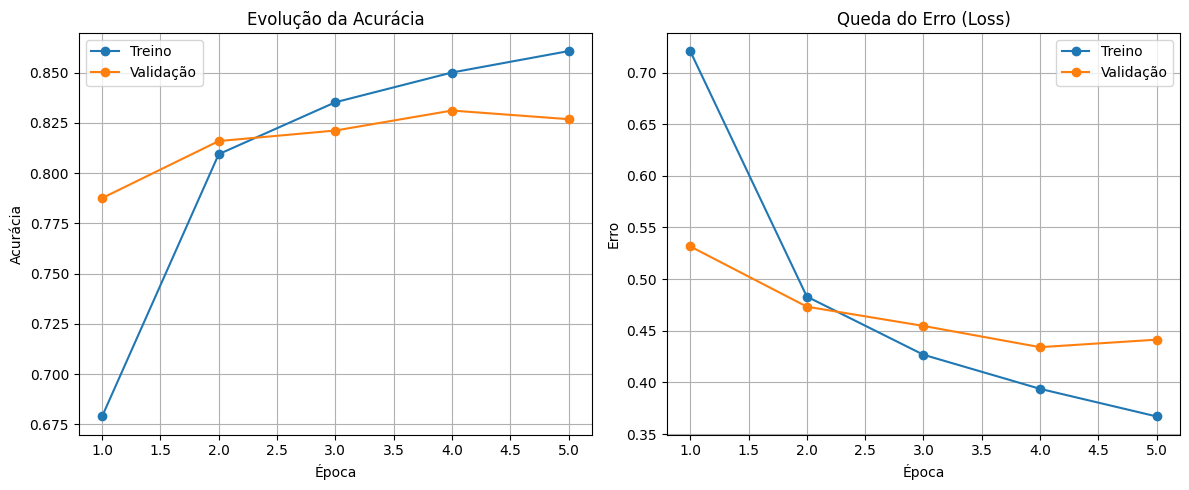

In [48]:
import matplotlib.pyplot as plt

# Definindo o tamanho da imagem
plt.figure(figsize=(12, 5))

# 1. Gráfico de Acurácia
plt.subplot(1, 2, 1)
# Usamos range(1, len(...)+1) para o eixo X começar em 1
epocas = range(1, len(history.history['accuracy']) + 1)
plt.plot(epocas, history.history['accuracy'], label='Treino', marker='o')
plt.plot(epocas, history.history['val_accuracy'], label='Validação', marker='o')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend()

# 2. Gráfico de Erro (Loss)
plt.subplot(1, 2, 2)
plt.plot(epocas, history.history['loss'], label='Treino', marker='o')
plt.plot(epocas, history.history['val_loss'], label='Validação', marker='o')
plt.title('Queda do Erro (Loss)')
plt.xlabel('Época')
plt.ylabel('Erro')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('grafico_treinamento_final.png') # Salva a imagem para o seu slide
plt.show()

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step


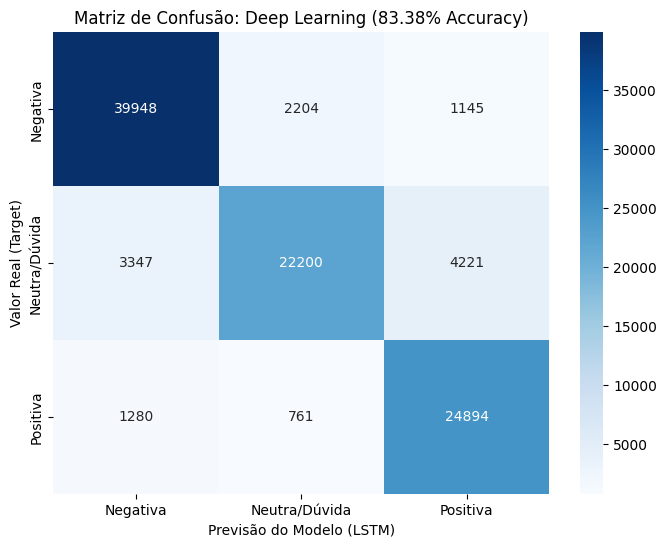

In [49]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Fazer as previsões na amostra de teste (X_deep)
# O modelo retorna probabilidades para as 3 classes
y_pred_probs = model.predict(X_deep)
y_pred_classes = np.argmax(y_pred_probs, axis=1) # Pega o índice da maior probabilidade

# 2. Criar a matriz de confusão comparando o Real (y_numeric) com o Previsto
cm = confusion_matrix(y_numeric, y_pred_classes)

# 3. Plotar o gráfico bonitão
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)

plt.xlabel('Previsão do Modelo (LSTM)')
plt.ylabel('Valor Real (Target)')
plt.title('Matriz de Confusão: Deep Learning (83.38% Accuracy)')
plt.show()

In [ ]:
# # Salva o modelo completo
# model.save('modelo_sentimento_lstm_marco.keras')

# print("Modelo de Deep Learning salvo com sucesso!")

Modelo de Deep Learning salvo com sucesso!


In [ ]:
# import joblib

# # Salva os tradutores de texto e rótulos
# joblib.dump(tokenizer, 'tokenizer_deep.pkl')
# joblib.dump(le, 'label_encoder_deep.pkl')

['label_encoder_deep.pkl']

Em resumo efetuamos os seguintes passos:

Limpeza de Big Data.

Engenharia de Features (Word2Vec).

Machine Learning Clássico (Baseline).

Deep Learning (LSTM) com 83% de sucesso.

Gráficos de Treinamento e Matriz de Confusão.


# Análise das Dores dos clientes

Nesta etapa, consolidamos o pipeline de inferência utilizando o dataset resultado_datathon.csv, já devidamente normalizado. A estratégia central foi a serialização e carga dos artefatos de Deep Learning (modelo .keras e tokenizer.pkl) previamente treinados. Essa abordagem não apenas otimiza o consumo de memória e tempo de processamento, mas garante a portabilidade do sistema. Esse design de software permite a integração imediata do modelo em aplicações de interface, como o Streamlit, transformando o script de análise em uma ferramenta operacional de monitoramento de sentimentos em tempo real.

Para a geração das visualizações finais, optamos por carregar os modelos de Deep Learning salvos em disco, evitando o re-treinamento desnecessário da rede neural. Esse método demonstra a eficiência do ciclo de vida do modelo (MLOps), onde os pesos da LSTM e os parâmetros do Tokenizer são preservados para uso futuro. Com essa estrutura, o projeto está tecnicamente pronto para ser escalado para um aplicativo interativo (Streamlit), focado na triagem automatizada das principais dores dos clientes.

Em vez de uma análise generalista, seccionamos o banco de dados por categorias de produto (ex: Credit Reporting, Debt Collection). Isso permitiu isolar queixas que possuem naturezas operacionais distintas.
Aplicamos a técnica de N-Gramas para identificar pares de palavras que ocorrem com frequência. Termos isolados como "cartão" dizem pouco, mas combinações como "identity theft" ou "unauthorized charge" revelam o problema raiz.
Geramos tabelas de frequência e Nuvens de Palavras segmentadas. Isso transformou dados não estruturados (textos de reclamações) em indicadores quantitativos, permitindo ranquear quais problemas causam maior impacto em cada setor do banco.
Cruzamos a frequência dos termos com o contexto do produto para sugerir ações preventivas, como melhoria em processos de segurança de dados ou novos scripts de atendimento.

In [3]:
df_ana = pd.read_csv('resultado_datathon.csv')

In [4]:
df_ana.head(5)

,Consumer complaint narrative,Product,narrativa_limpa,narrativa_stemmed,tokens_stemmed,sentimento
0,These are not my accounts.,"Credit reporting, credit repair services, or o...",account,account,['account'],Neutra/Dúvida
1,Kindly address this issue on my credit report....,Credit reporting or other personal consumer re...,kindly address issue credit report assert acco...,kindli address issu credit report assert accou...,"['kindli', 'address', 'issu', 'credit', 'repor...",Neutra/Dúvida
2,"I wrote three requests, the unverified account...","Credit reporting, credit repair services, or o...",wrote three request unverified account listed ...,wrote three request unverifi account list stil...,"['wrote', 'three', 'request', 'unverifi', 'acc...",Negativa
3,XXXX XXXX has a old account settled in XXXX th...,"Credit reporting, credit repair services, or o...",old account settled keep reappearing experian ...,old account settl keep reappear experian credi...,"['old', 'account', 'settl', 'keep', 'reappear'...",Neutra/Dúvida
4,They call at all hours and on the weekends usi...,Student loan,call hour weekend using various number,call hour weekend use variou number,"['call', 'hour', 'weekend', 'use', 'variou', '...",Neutra/Dúvida


Carregando modelo e tokenizer...
Carregando dados novos...
Preparando dados e realizando previsões (mostragem)...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step
Filtrando reclamações negativas detectadas pelo modelo...
Gerando gráficos para os top 3 produtos: ['Credit reporting or other personal consumer reports', 'Credit reporting, credit repair services, or other personal consumer reports', 'Debt collection']...


C:\Users\marco\AppData\Local\Temp\ipykernel_3320\3336449156.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contagem', y='Palavra', data=df_frequencia, palette='Reds_r')


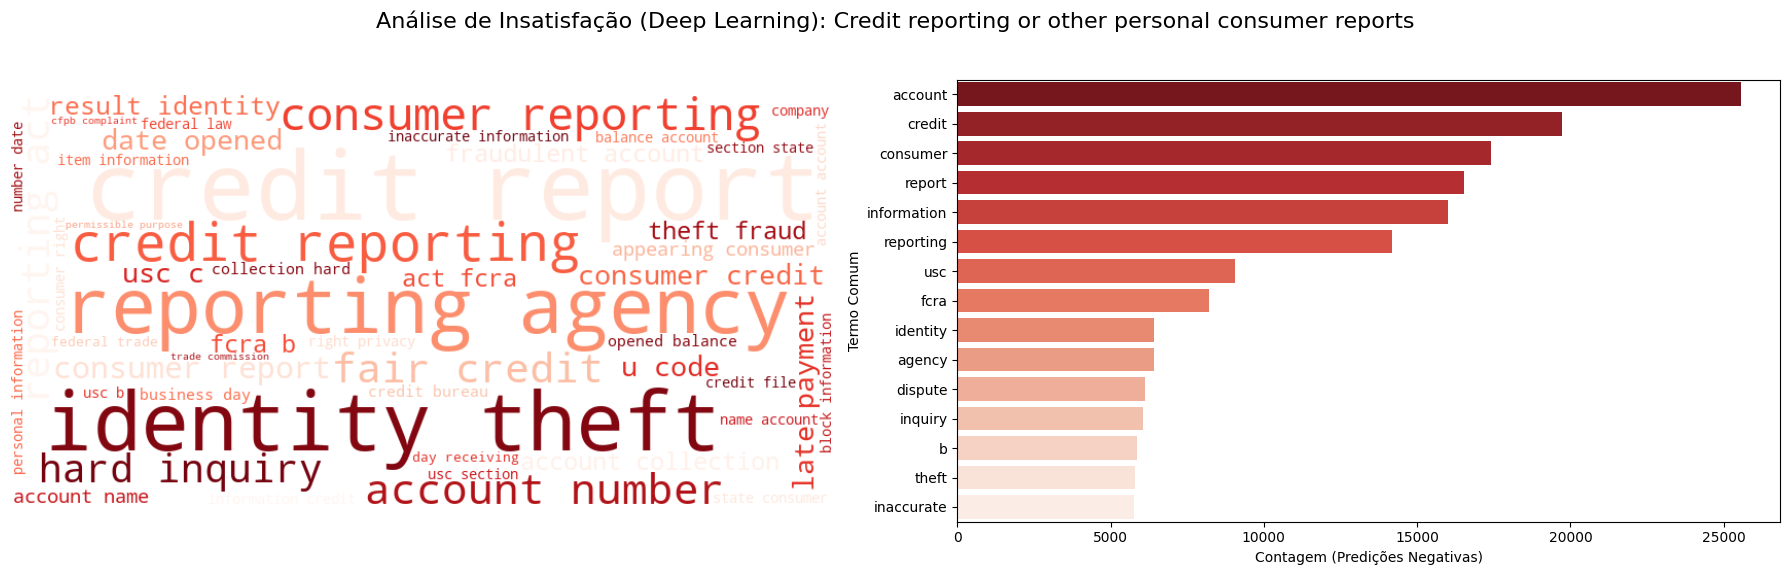

C:\Users\marco\AppData\Local\Temp\ipykernel_3320\3336449156.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contagem', y='Palavra', data=df_frequencia, palette='Reds_r')


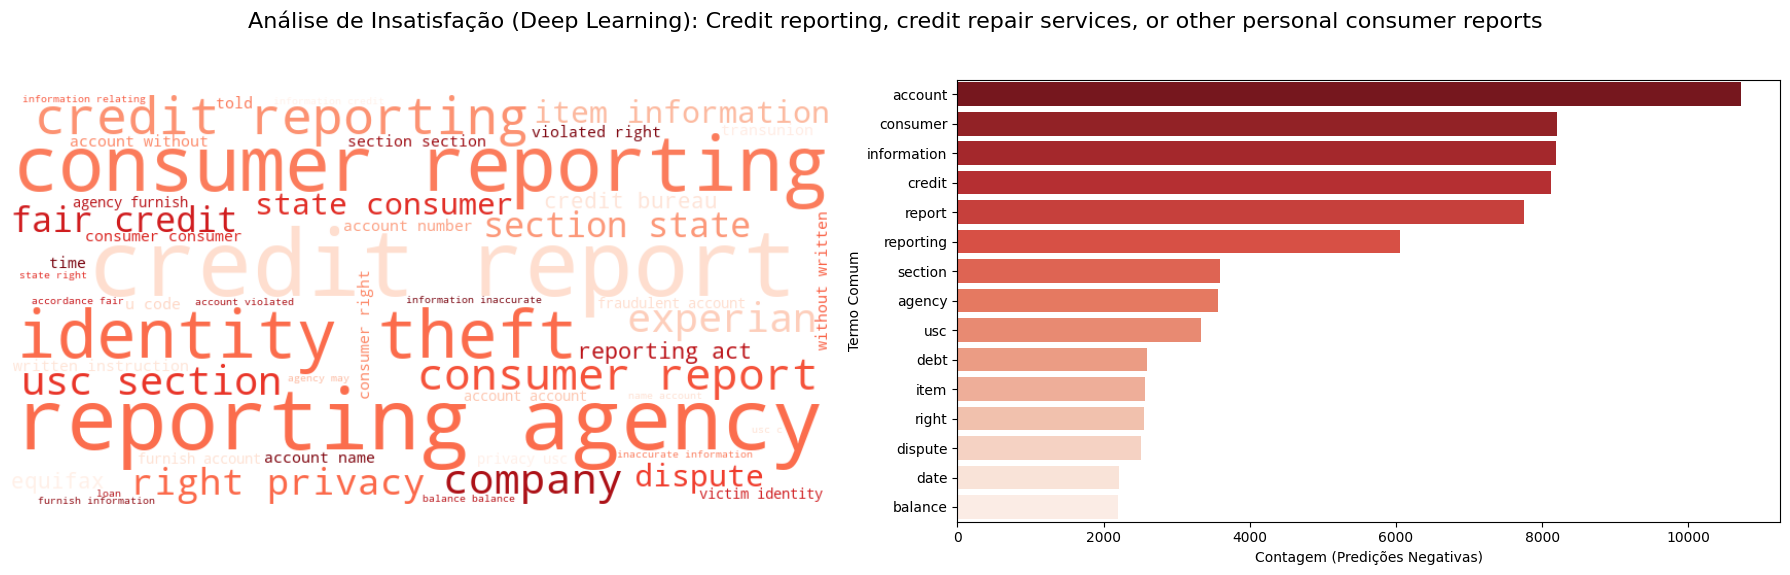

C:\Users\marco\AppData\Local\Temp\ipykernel_3320\3336449156.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contagem', y='Palavra', data=df_frequencia, palette='Reds_r')


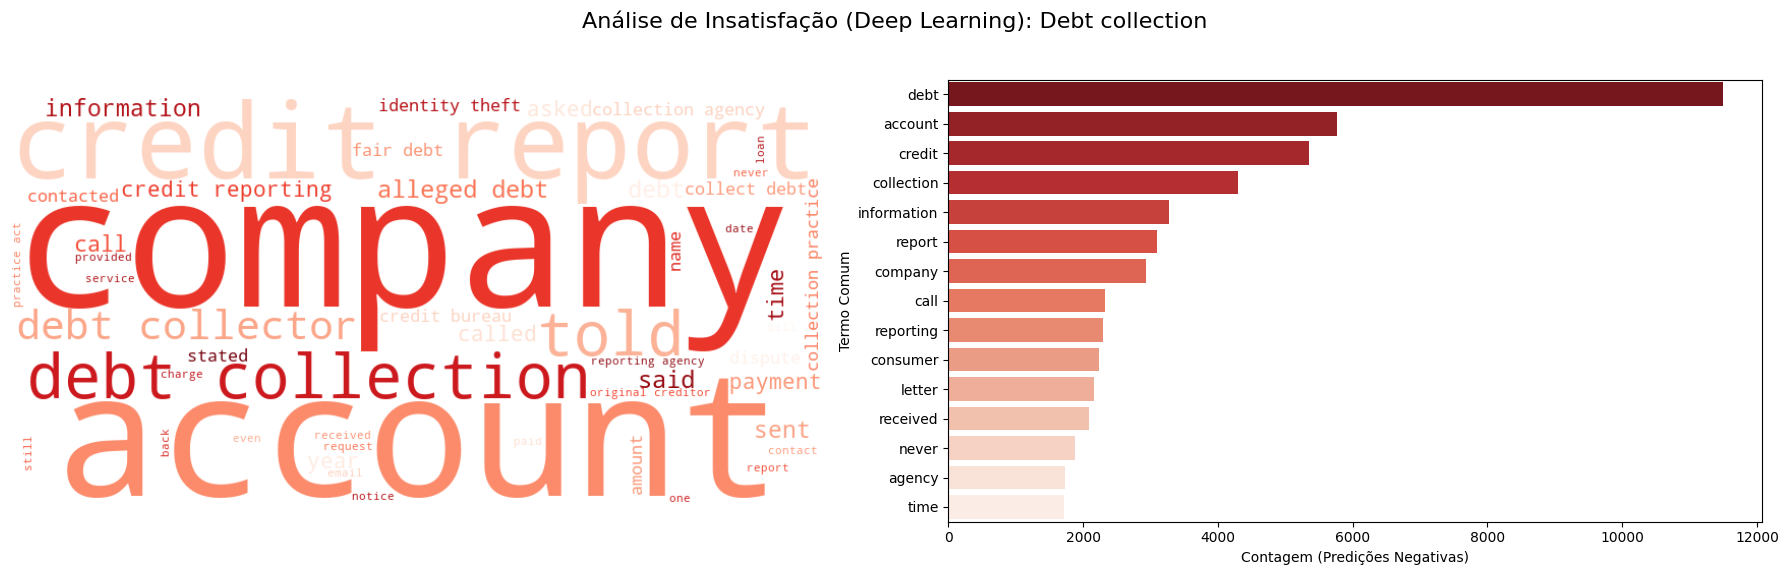

Análise concluída com sucesso!


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences


# Carregar o modelo de Deep Learning (LSTM) e o Tokenizer que salvamos
print("Carregando modelo e tokenizer...")
model = load_model('modelo_sentimento_lstm_marco.keras')
tokenizer = joblib.load('tokenizer_deep.pkl') # Essencial para traduzir o texto novo

# Carregar o novo DataFrame (com a coluna 'product')

print("Carregando dados novos...")
df_ana = pd.read_csv('resultado_datathon.csv')


print("Preparando dados e realizando previsões (mostragem)...")
df_viz = df_ana.sample(50000, random_state=42).reset_index(drop=True)

# Transformar o texto limpo em sequências numéricas (Padding)
# (Assumindo que a coluna de texto limpo é 'narrativa_limpa' e max_len é 100)
sequences = tokenizer.texts_to_sequences(df_viz['narrativa_limpa'].astype(str))
X_input = pad_sequences(sequences, maxlen=100)

# Predição: A rede neural decide o sentimento de cada linha
preds = model.predict(X_input)

# Pega o índice da classe com maior probabilidade (0, 1 ou 2)
# (Assumindo que 0 é 'Negativa' no seu LabelEncoder)
df_viz['sentimento_predito'] = np.argmax(preds, axis=1)


# Manter apenas o que a IA classificou como Negativo
print("Filtrando reclamações negativas detectadas pelo modelo...")
df_negativas_modelo = df_viz[df_viz['sentimento_predito'] == 0]

# Identificar os 3 produtos com maior volume de reclamações negativas
top_produtos = df_negativas_modelo['Product'].value_counts().nlargest(3).index

#  GERAÇÃO DE VISUALIZAÇÕES POR PRODUTO ---
print(f"Gerando gráficos para os top 3 produtos: {top_produtos.tolist()}...")

for produto in top_produtos:
    # Agrupar todo o texto negativo daquele produto
    df_produto = df_negativas_modelo[df_negativas_modelo['Product'] == produto]
    texto_produto = " ".join(df_produto['narrativa_limpa'].astype(str))
    
    # Se houver muito pouco texto, pular
    if len(texto_produto) < 100:
        continue

    # Criar e configurar a Nuvem de Palavras (WordCloud)
    wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=50).generate(texto_produto)
    
    # Criar a figura com dois subplots (Nuvem e Barras)
    plt.figure(figsize=(18, 6))
    plt.suptitle(f"Análise de Insatisfação (Deep Learning): {produto}", fontsize=16)

    # Subplot 1: WordCloud
    plt.subplot(1, 2, 1)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    
    # Subplot 2: Gráfico de Barras (Top 15 Termos)
    plt.subplot(1, 2, 2)
    palavras = texto_produto.split()
    df_frequencia = pd.DataFrame(Counter(palavras).most_common(15), columns=['Palavra', 'Contagem'])
    sns.barplot(x='Contagem', y='Palavra', data=df_frequencia, palette='Reds_r')
    plt.xlabel("Contagem (Predições Negativas)")
    plt.ylabel("Termo Comum")

    # Mostrar o gráfico final
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("Análise concluída com sucesso!")

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Filtramos apenas o que a sua LSTM classificou como 'Negativo'
df_neg = df_viz[df_viz['sentimento_predito'] == 0]

# 2. Criamos uma função para extrair os temas (Bigrams)
def extrair_top_temas(texto_serie, n_temas=10):
    # ngram_range=(2,2) busca duplas de palavras, que dão mais contexto que palavras soltas
    vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=n_temas)
    ngram_matrix = vectorizer.fit_transform(texto_serie.astype(str))
    
    counts = ngram_matrix.toarray().sum(axis=0)
    temas = vectorizer.get_feature_names_out()
    
    return pd.DataFrame({'Tema de Insatisfação': temas, 'Ocorrências': counts}).sort_values(by='Ocorrências', ascending=False)

# 3. Gerar a tabela global de dores do cliente
tabela_temas = extrair_top_temas(df_neg['narrativa_limpa'])

print("=== TOP 10 TEMAS DE INSATISFAÇÃO IDENTIFICADOS PELA IA ===")
print(tabela_temas.to_string(index=False))

=== TOP 10 TEMAS DE INSATISFAÇÃO IDENTIFICADOS PELA IA ===
Tema de Insatisfação  Ocorrências
       credit report        12754
      identity theft         8239
    reporting agency         8162
    credit reporting         7113
  consumer reporting         5857
      account number         4236
         fair credit         4180
     consumer report         4111
       reporting act         3996
     account account         3408
